# What gets a player drafted vs. what earns NBA minutes?

This notebook compares two chronological XGBoost models using the same 87 NCAA predictors. Stage 1 predicts draft entry among Combine participants. Stage 2 predicts first-three-season NBA minutes among drafted members of that cohort. A third sensitivity model adds draft position to Stage 2.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'results').exists():
    raise FileNotFoundError('Run from the repository root or notebooks directory.')

RESULTS_DIR = REPO_ROOT / 'results'
summary = json.loads((RESULTS_DIR / 'two_stage_feature_importance_summary.json').read_text())
groups = pd.read_csv(RESULTS_DIR / 'two_stage_group_permutation_importance.csv')
features = pd.read_csv(RESULTS_DIR / 'two_stage_shared_feature_comparison.csv')
sns.set_theme(style='whitegrid', context='notebook')

## Study design

The shared contract makes the importance comparison meaningful. Draft position is deliberately excluded because it is assigned after the entry decision. The draft-capital sensitivity model is shown separately.

In [2]:
performance = summary['model_performance']
display(pd.DataFrame([
    {'model': 'Entry: college-only', 'population': 'All Combine participants', 'metric': 'Average precision', 'value': performance['entry_college_only_average_precision']},
    {'model': 'Minutes: college-only', 'population': 'Drafted Combine participants', 'metric': 'R²', 'value': performance['minutes_college_only_r2']},
    {'model': 'Minutes: college + draft capital', 'population': 'Same drafted cohort', 'metric': 'R²', 'value': performance['minutes_college_plus_draft_capital_r2_same_cohort']},
]))
display(pd.DataFrame([summary['cohorts']]))

,model,population,metric,value
0,Entry: college-only,All Combine participants,Average precision,0.762923
1,Minutes: college-only,Drafted Combine participants,R²,-0.014562
2,Minutes: college + draft capital,Same drafted cohort,R²,0.426686


,entry_test_rows,entry_test_drafted,minutes_test_rows,years
0,202,124,124,"[2020, 2021, 2022]"


## Concept-level importance

Each concept is shuffled jointly within draft year 30 times. The chart normalizes positive importance within each model because AP loss and RMSE increase have different units. Negative importance is displayed as zero in the share and remains available in the CSV.

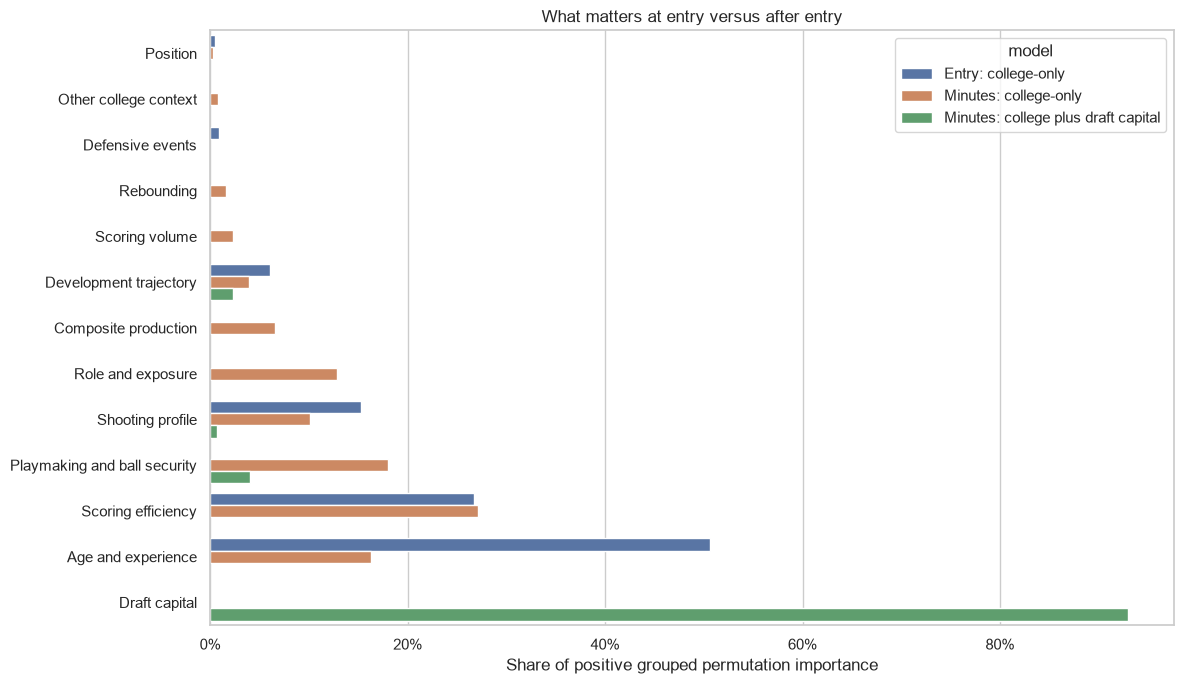

In [3]:
plot_groups = groups[groups['positive_importance_share'] > 0].copy()
order = (plot_groups.groupby('item')['positive_importance_share'].max().sort_values().index)
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=plot_groups, x='positive_importance_share', y='item', hue='model', order=order, ax=ax)
ax.set(xlabel='Share of positive grouped permutation importance', ylabel='', title='What matters at entry versus after entry')
ax.xaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
plt.tight_layout()
plt.show()

In [4]:
for model_name in groups['model'].unique():
    display(Markdown(f'### {model_name}'))
    display(groups[groups['model'].eq(model_name)].sort_values('rank').head(8)[
        ['item', 'importance_mean', 'importance_ci_low', 'importance_ci_high', 'positive_importance_share']
    ].style.format({'importance_mean': '{:.3f}', 'importance_ci_low': '{:.3f}', 'importance_ci_high': '{:.3f}', 'positive_importance_share': '{:.1%}'}))

### Entry: college-only

,item,importance_mean,importance_ci_low,importance_ci_high,positive_importance_share
0,Age and experience,0.082,0.033,0.136,50.7%
1,Scoring efficiency,0.043,0.014,0.066,26.7%
2,Shooting profile,0.025,0.010,0.040,15.3%
3,Development trajectory,0.010,-0.011,0.022,6.1%
4,Defensive events,0.001,-0.016,0.028,0.9%
5,Position,0.001,-0.001,0.002,0.5%
6,Other college context,-0.002,-0.008,0.006,0.0%
7,Rebounding,-0.002,-0.006,0.002,0.0%


### Minutes: college-only

,item,importance_mean,importance_ci_low,importance_ci_high,positive_importance_share
12,Scoring efficiency,33.272,4.829,58.145,27.2%
13,Playmaking and ball security,22.082,8.707,44.185,18.0%
14,Age and experience,19.930,-74.082,100.084,16.3%
15,Role and exposure,15.709,6.178,22.442,12.8%
16,Shooting profile,12.348,-7.562,34.338,10.1%
17,Composite production,8.039,-5.185,22.401,6.6%
18,Development trajectory,4.794,-3.486,14.793,3.9%
19,Scoring volume,2.885,-4.569,10.370,2.4%


### Minutes: college plus draft capital

,item,importance_mean,importance_ci_low,importance_ci_high,positive_importance_share
24,Draft capital,784.691,600.534,953.580,93.0%
25,Playmaking and ball security,34.309,-3.063,73.675,4.1%
26,Development trajectory,19.141,2.241,38.797,2.3%
27,Shooting profile,5.774,-35.226,28.787,0.7%
28,Other college context,0.000,0.000,0.000,0.0%
29,Scoring volume,-0.043,-2.062,2.118,0.0%
30,Defensive events,-0.178,-2.194,3.488,0.0%
31,Composite production,-1.164,-2.882,1.019,0.0%


## Shared individual features

Individual rankings are secondary because correlated raw, career, and engineered features can split or mask one another's importance.

In [5]:
display(Markdown('### Most important for getting drafted'))
display(features.sort_values('entry_rank').head(15)[['feature', 'concept', 'entry_ap_decrease', 'entry_rank', 'minutes_rank']])
display(Markdown('### Most important for minutes in the college-only model'))
display(features.sort_values('minutes_rank').head(15)[['feature', 'concept', 'minutes_rmse_increase', 'minutes_rank', 'entry_rank']])

### Most important for getting drafted

,feature,concept,entry_ap_decrease,entry_rank,minutes_rank
73,college_age_adjusted_stocks,Age and experience,0.048386,1,87
72,college_age_adjusted_scoring,Age and experience,0.018658,2,85
14,college_last_ts_pct,Scoring efficiency,0.008835,3,9
4,college_last_minutes,Role and exposure,0.007890,4,8
10,college_last_fg_pct,Scoring efficiency,0.005513,5,64
39,college_career_efg_pct,Scoring efficiency,0.005422,6,10
61,college_development_rebounds_per_40_delta,Development trajectory,0.004930,7,63
84,college_last_three_pct_shrunk,Shooting profile,0.004619,8,35
11,college_last_three_pct,Shooting profile,0.003090,9,78
40,college_career_ts_pct,Scoring efficiency,0.002974,10,3


### Most important for minutes in the college-only model

,feature,concept,minutes_rmse_increase,minutes_rank,entry_rank
9,college_last_free_throws_attempted,Shooting profile,10.182176,1,67
30,college_career_minutes,Role and exposure,8.707174,2,60
40,college_career_ts_pct,Scoring efficiency,7.803773,3,10
76,college_career_production_index,Composite production,5.820245,4,71
60,college_development_points_per_40_delta,Development trajectory,5.536077,5,83
50,college_career_assist_turnover_ratio,Playmaking and ball security,5.367194,6,37
35,college_career_free_throws_attempted,Shooting profile,4.844803,7,62
4,college_last_minutes,Role and exposure,4.688417,8,4
14,college_last_ts_pct,Scoring efficiency,4.455749,9,3
39,college_career_efg_pct,Scoring efficiency,3.836657,10,6


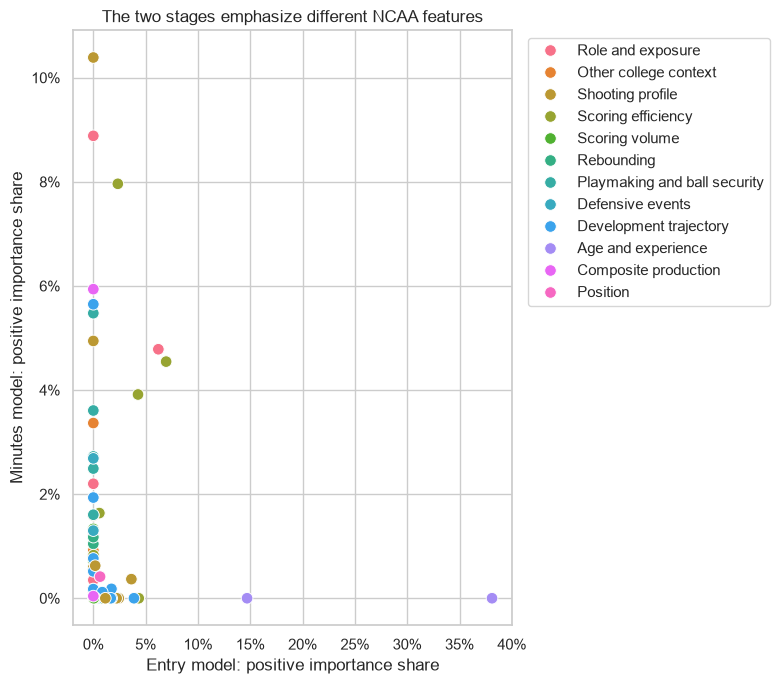

In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
positive = features[(features['entry_positive_share'] > 0) | (features['minutes_positive_share'] > 0)].copy()
sns.scatterplot(data=positive, x='entry_positive_share', y='minutes_positive_share', hue='concept', ax=ax, s=70)
ax.set(xlabel='Entry model: positive importance share', ylabel='Minutes model: positive importance share', title='The two stages emphasize different NCAA features')
ax.xaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
ax.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Interpretation

The entry model relies primarily on age/experience, scoring efficiency, and shooting. College-only playing-time prediction does not generalize on 2020–22 (R² below zero), so its internal ranking is exploratory. Once draft capital is added, same-cohort R² rises to about 0.427 and draft capital accounts for roughly 93% of positive grouped importance.

The defensible conclusion is predictive rather than causal: college traits help distinguish who crosses the NBA threshold, while early opportunity after selection is dominated by information and investment summarized by draft slot. This does not prove that draft position causes minutes. The populations are Combine participants and drafted Combine participants, not all NCAA players.